# Wildfire Detection and Visualization in Europe 

This project uses near real-time wildfire data provided by NASA's FIRMS (Fire Information for Resource Management System) to identify and visualize active fire detections across Europe.

The workflow begins by accessing the latest MODIS fire detection data through the NASA API. The dataset is then filtered to retain only observations located within Europe and the most relevant attributes are selected for further analysis. After cleaning and preparing the data, the fire detections are converted into a GeoDataFrame to enable spatial operations and geographic visualizations.

Several visualizations are produced:

- An interactive map displaying wildfire detections classified by confidence level and differentiated between day and night detections.
- A second interactive map displaying wildfire detections classified by confidence level and differentiate based on Fire Radiative Power (FRP).
- A spatial analysis that assigns wildfire detections to European countries using a spatial join.
- A choropleth map illustrating the number of detected wildfires per country.

The overall objective of this project is to provide a clear overview of the spatial distribution, intensity and concentration of wildfire activity across Europe using both interactive and static geospatial visualizations.

---

<small><span style="color:gray">
Note: Marker clustering was intentionally not used in the interactive maps. While clustering improves readability in areas with many observations, it limits the ability to customize marker colors based on attributes such as day/night detection or fire intensity. Preserving these visual distinctions was considered more important for the objectives of this analysis.
</span></small>


In [1]:
# 1. IMPORT EVERY LIBRARY NEEDED
#----------------------------------------------------#
import requests
import pandas as pd
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx

In [2]:
# 2. ACESS TO THE WEBSITE AND DATA
#----------------------------------------------------#

# Personal Key -> Needed to have access
NASA_API_KEY = "13b5670c616665b924e5aad3a18a24e2"

# Define the API
api_url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{NASA_API_KEY}/MODIS_NRT/world/5"

# Send request
response = requests.get(api_url)

# Checking if it works
print(response.status_code) # 200 (means OK), 404 (means not working)

200


In [3]:
# 3. CLEANING AND FILTERING DATA 
#----------------------------------------------------#

# Reading the data
data = pd.read_csv(api_url, sep=",")

#-----------------------------------
# Checking 
#display(data)
#-----------------------------------

# Selecting only Europe and filtering the useful attribute 
data_europe = data[(data['longitude'] >= -27) & (data['latitude'] >= 34) & (data['longitude'] <= 43) & (data['latitude'] <= 72)].copy()
Selec_europe_data = data_europe[["latitude", "longitude", "frp", "daynight", "confidence"]].copy()

#-----------------------------------
# Checking
#display(data_europe)
#display(Selec_europe_data)
#-----------------------------------

# Overview of the data (Column, Dtype)
Selec_europe_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 617 entries, 172 to 24298
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   latitude    617 non-null    float64
 1   longitude   617 non-null    float64
 2   frp         617 non-null    float64
 3   daynight    617 non-null    object 
 4   confidence  617 non-null    int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 28.9+ KB


In [4]:
# 4. PREPARING THE DATA FOR VISUALISATION 
#----------------------------------------------------#

# Convert the data into GeoDataFrame (Geographical Coordinates)
wildfire_europe_gdf = gpd.GeoDataFrame(
    Selec_europe_data, 
    geometry = gpd.points_from_xy(Selec_europe_data["longitude"], Selec_europe_data["latitude"])) # -> x=longitude, y=latitude

#-----------------------------------
# Checking the transformation
#display(wildfire_europe_gdf.head(3)) # -> Works if new attribute called "geometry"
#-----------------------------------

# Checking and Setting a crs if not already set
print(wildfire_europe_gdf.crs) # ->In this case None (!Needs to be set!)
wildfire_europe_gdf = wildfire_europe_gdf.set_crs(epsg=4326) 

None


In [5]:
# 5. PREPARING THE DATA FURTHER (TWO SETS BASED ON CONFIDENCE) AND INITIATING WEB APP
#----------------------------------------------------#

# Initiating an empty Web App for Day/Night
fire_daynight_map = folium.Map(
    location=[55, 20], 
    zoom_start = 4 , # More zoom the higher the number
    tiles= "Stadia.AlidadeSmoothDark") # BaseMap

# Initiating an empty Web App for Firepower
fire_frp_map = folium.Map(
    location=[55, 20], 
    zoom_start = 4 , # More zoom the higher the number
    tiles= "Stadia.AlidadeSmoothDark") # BaseMap

# Filtering Data over/under 50 confidence
wildfire_over = wildfire_europe_gdf [wildfire_europe_gdf["confidence"] >= 50]
wildfire_under = wildfire_europe_gdf [wildfire_europe_gdf["confidence"] < 50]

In [6]:
# 6. VISUALIZE THE DATA - FIRST TWO MAPS (COLORED BY DAYNIGHT AND SORTED BY CONFIDENCE)
#----------------------------------------------------#

# Create layers
high_layer = folium.FeatureGroup(name="Verified Fire Detections")
low_layer = folium.FeatureGroup(name="Uncertain Fire Detections")

# Create Coloring settings
def daynight_color(daynight):
    if daynight == "D":
        return "red"
    elif daynight == "N":
        return "darkred"
    else:
        return "gray"


# 1. High confidence fires (with tooltip)
for idx, row in wildfire_over.iterrows():  
    # Extract coordinates
    lat = row.geometry.y
    lon = row.geometry.x

    # Format the tooltip text
    tooltip_text = (
        f"</b>Intensity:</b> {row['frp']}"
    )
    
    # Create the marker
    folium.Marker(
        location=[lat, lon],
        icon=folium.Icon(color=daynight_color(row["daynight"]), icon="fire"),
        tooltip=tooltip_text,
    ).add_to(high_layer)

    

# 2. Low confidence fires (with tooltip)
for idx, row in wildfire_under.iterrows():  
    # Extract coordinates
    lat = row.geometry.y
    lon = row.geometry.x

    # Format the tooltip text explicitly
    tooltip_text = (
            f"<b>Intensity:</b> {row['frp']}"
        )
    
    # Create the individual marker 
    folium.Marker(
        location=[lat, lon],
        icon=folium.Icon(color=daynight_color(row["daynight"]), icon="fire"),
        tooltip=tooltip_text,
    ).add_to(low_layer)


# Adding Layer and control to Map
high_layer.add_to(fire_daynight_map)
low_layer.add_to(fire_daynight_map)
folium.LayerControl().add_to(fire_daynight_map)

# Adding a legend
legend_daynight_html = """
<div style="
    position: fixed; 
    bottom: 20px;
    left: 20px;
    width: 110;
    height: 80px;
    background-color: white;
    border:2px solid grey;
    z-index:9999;
    font-size:13px;
    padding:10px
">
<b>Day / Night</b><br>

<i style="background:red;
          width:10px;
          height:10px;
          float:left;
          margin-right:8px;">
</i> Day Fire<br>

<i style="background:darkred;
          width:10px;
          height:10px;
          float:left;
          margin-right:8px;">
</i> Night Fire<br>

</div>
"""
fire_daynight_map.get_root().html.add_child(folium.Element(legend_daynight_html))


# Displaying the map
fire_daynight_map

In [7]:
# 7. VISUALIZE THE DATA - THIRD MAP (COLORED BY FRP)
#----------------------------------------------------#

#Create layers
gradient_high_confidence = folium.FeatureGroup(name="Verified Fire Intensity")
gradient_low_confidence = folium.FeatureGroup(name="Uncertain Fire Intensity")

# Create Gradient (Marker dont support gradient)
def gradient(frp):
    if frp <= 10:
        return "orange"
    elif 10 < frp <= 60:
        return "red"
    else:
        return "darkred"

# 3. High confidence with gradient (with tooltip)
for idx, row in wildfire_over.iterrows():  
    # Extract coordinates
    lat = row.geometry.y
    lon = row.geometry.x

    # Format the tooltip text explicitly
    tooltip_text = (
        f"<b>Day/Night:</b> {row['daynight']}"
    )
    
    # Create the marker
    folium.Marker(
        location=[lat, lon],
        icon=folium.Icon(color=gradient(row["frp"]), icon="fire"),
        tooltip=tooltip_text,
    ).add_to(gradient_high_confidence)

# 4. Low confidence with gradient (with tooltip)
for idx, row in wildfire_under.iterrows():  
    # Extract coordinates
    lat = row.geometry.y
    lon = row.geometry.x

    # Format the tooltip text explicitly
    tooltip_text = (
        f"<b>Day/Night:</b> {row['daynight']}<br>"
    )
    
    # Create the individual marker
    folium.Marker(
        location=[lat, lon],
        icon=folium.Icon(color=gradient(row["frp"]), icon="fire"),
        tooltip=tooltip_text,
    ).add_to(gradient_low_confidence)

# Adding Layer and control to Map
gradient_high_confidence.add_to(fire_frp_map)
gradient_low_confidence.add_to(fire_frp_map)
folium.LayerControl().add_to(fire_frp_map)


# Adding a legend
legend_frp_html = """
<div style="
    position: fixed; 
    bottom: 20px;
    left: 20px;
    width: 220;
    height: 110px;
    background-color: white;
    border:2px solid grey;
    z-index:9999;
    font-size:15px;
    padding:10px
">
<b>FRP Intensity</b><br>

<i style="background:orange;
          width:10px;
          height:10px;
          float:left;
          margin-right:8px;">
</i> Low (0-10)<br>

<i style="background:red;
          width:10px;
          height:10px;
          float:left;
          margin-right:8px;">
</i> Medium (10-60)<br>

<i style="background:darkred;
          width:10px;
          height:10px;
          float:left;
          margin-right:8px;">
</i> Extreme (60+)<br>
</div>
"""
fire_frp_map.get_root().html.add_child(folium.Element(legend_frp_html))


# Displaying the map
fire_frp_map 

In [8]:
# 8. PREPARING DATA FOR COUNT - SPATIAL JOINT
#----------------------------------------------------#

# Loading European countries and set it to the same crs
europe_countries = gpd.read_file("data/Europe_merged.shp").to_crs(epsg=4326)

# Simplyfy the geometry of the countries (Or else it takes to long)
europe_simple = europe_countries.copy()

europe_simple["geometry"] = europe_simple.geometry.simplify(tolerance=0.1)


#-----------------------------------
# Checking the information in the shapefile
#print(europe_countries.head())
#-----------------------------------

# Spatial join: Wildfires with Countries
fires_per_country_join = gpd.sjoin(
    wildfire_over,
    europe_simple,
    how="left",
    predicate="within"
)

# Count number of fires per country and convert back to DataFrame
fire_counts_group = fires_per_country_join.groupby("COUNTRY").size()
fire_count = fire_counts_group.reset_index(name="fire_count")

#-----------------------------------
# Checking the five countries with the most wildfires
display(fire_counts_group.sort_values(ascending=False).head(5))
#-----------------------------------

# Merge fire counts with countries polygons
fire_counts_merge = europe_simple.merge(
    fire_count, 
    on="COUNTRY", 
    how="left"
)

# Fill any countries with a 0 instead of NaN 
fire_counts_merge["fire_count"] = fire_counts_merge["fire_count"].fillna(0)

COUNTRY
Turkey     95
Italy      91
Germany    30
Spain      22
Poland     18
dtype: int64

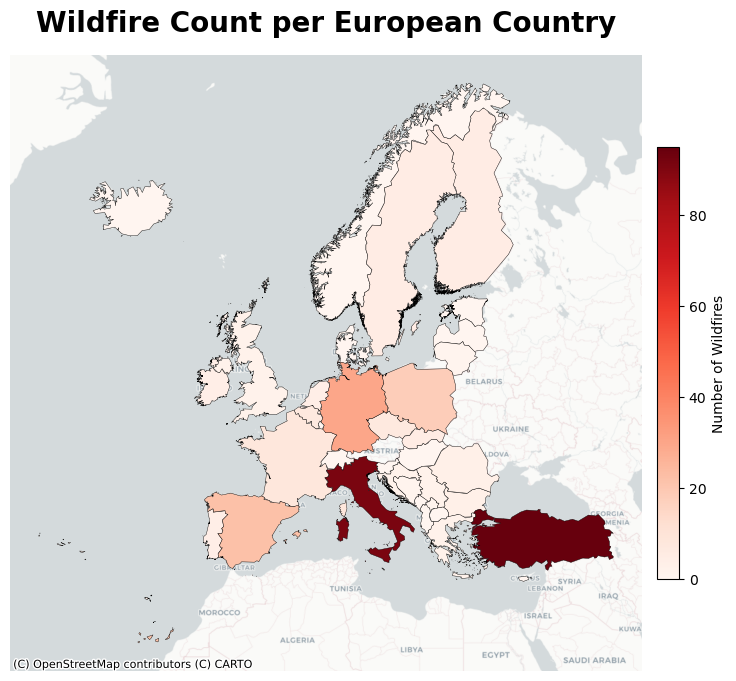

In [9]:
# 9. VISUALIZE FIRE PER COUNTRY (STATIC CHLOROPLETH)
#----------------------------------------------------#

# Create the overarching Figure
fig, ax = plt.subplots(figsize=(10, 8))

# Reproject to Web Mercator for basemap compatibility
fire_counts_webmercator = fire_counts_merge.to_crs(epsg=3857)

# Legend settings
legend_options = {
    "label": "Number of Wildfires",
    "orientation": "vertical",
    "shrink": 0.7,
    "pad": 0.02,
}

# Plotting the countries
fire_counts_webmercator.plot(
    ax=ax,
    column="fire_count", 
    cmap="Reds", 
    legend=True,
    legend_kwds=legend_options,
    edgecolor="black", 
    linewidth=0.3, 
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)


# Title and remove axis
ax.set_title("Wildfire Count per European Country", fontsize=20, fontweight="bold")
ax.axis("off")

plt.show()

